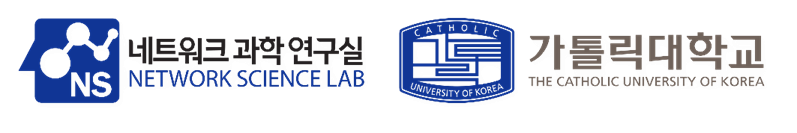

# Graph Isomorphism and Graph Kernels
This notebook covers fundamental concepts in graph matching and comparison:
1. **VF2 Algorithm**: Finding graph isomorphisms.
2. **Weisfeiler Lehman (WL) Graph Hash**: Hashing graphs to check for isomorphism.
3. **Graphlet Kernels**: Extracting and analyzing subgraph patterns.
4. **Chemical Graph Kernels**: Using Shortest Path and Random Walk kernels on molecule graphs.

## Setup and Installation
Install the necessary python libraries:

In [2]:
!pip install networkx pandas matplotlib grakel numpy==1.23.5 scipy==1.9.3

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import itertools
import random
from networkx.algorithms import isomorphism
from grakel import Graph
from grakel.kernels import ShortestPath, RandomWalk

# 1. VF2 Algorithm for Graph Isomorphism
The VF2 algorithm is used for graph isomorphism. It can be used to check if two graphs are structurally equivalent.
## 1.1. Undirected graph

In [4]:
# Generate 2 graphs
G1 = nx.Graph()
G2 = nx.Graph()

G1.add_nodes_from(range(0,7))
G2.add_nodes_from(range(0,7))
G1.add_edges_from([(0,1), (1,2), (2,3), (3,4), (2,5), (5,6)])
G2.add_edges_from([(0,1), (1,4), (2,4), (2,6), (4,3), (3,5)])

# Mapping 2 graph G1 and G2
GM = isomorphism.GraphMatcher(G2,G1)
print(f" Checking graph isomorphic: {GM.is_isomorphic()}")
GM.mapping

 Checking graph isomorphic: True


{0: 0, 1: 1, 4: 2, 2: 3, 6: 4, 3: 5, 5: 6}

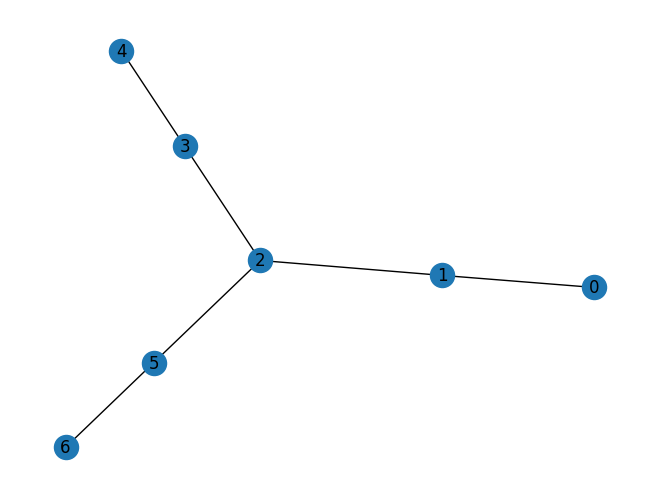

In [5]:
nx.draw(G1, with_labels = True)

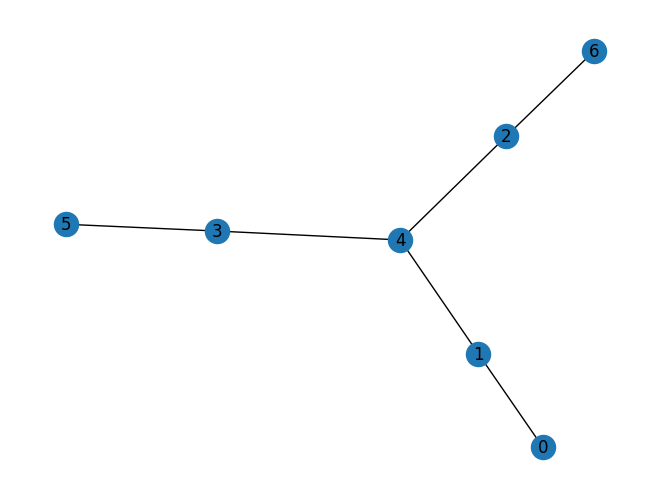

In [6]:
nx.draw(G2, with_labels = True)

## 1.2. Directed graph

In [7]:
# Generate 2 graphs
G1 = nx.DiGraph()
G2 = nx.DiGraph()

G1.add_nodes_from(range(0,7))
G2.add_nodes_from(range(0,7))
G1.add_edges_from([(0,1), (1,2), (2,3), (3,4), (2,5), (5,6)])
G2.add_edges_from([(0,1), (1,4), (2,4), (2,6), (4,3), (3,5)])

# Mapping 2 graph G1 and G2
GM = isomorphism.GraphMatcher(G2,G1)
print(f" Checking graph isomorphic: {GM.is_isomorphic()}")
GM.mapping

 Checking graph isomorphic: False


{}

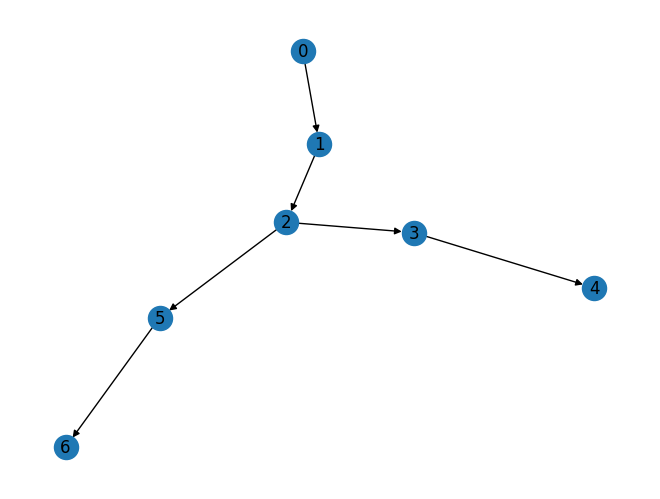

In [8]:
nx.draw(G1, with_labels = True)

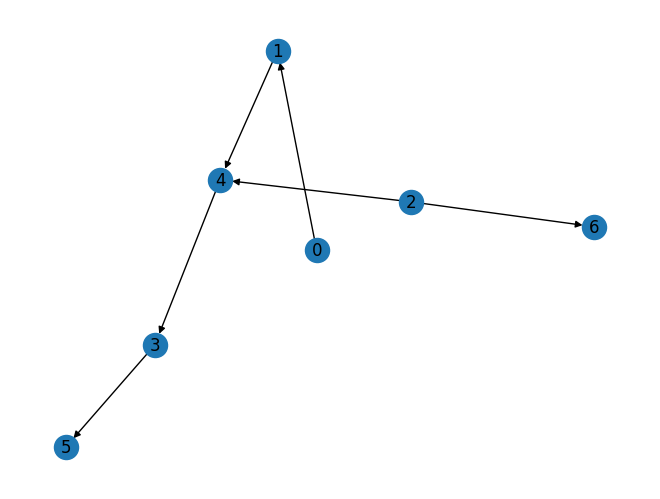

In [9]:
nx.draw(G2, with_labels = True)

In [10]:
# Generate 2 directed graphs
G1 = nx.DiGraph()
G2 = nx.DiGraph()

G1.add_nodes_from(range(0,7))
G2.add_nodes_from(range(0,7))
# Change graph edges
G1.add_edges_from([(0,1), (1,2), (2,3), (3,4), (2,5), (5,6)])
G2.add_edges_from([(0,1), (1,4), (4,2), (2,6), (4,3), (3,5)])

# Mapping 2 graph G1 and G2
GM = isomorphism.GraphMatcher(G2,G1)
print(f" Checking graph isomorphic: {GM.is_isomorphic()}")
GM.mapping

 Checking graph isomorphic: True


{0: 0, 1: 1, 4: 2, 2: 3, 6: 4, 3: 5, 5: 6}

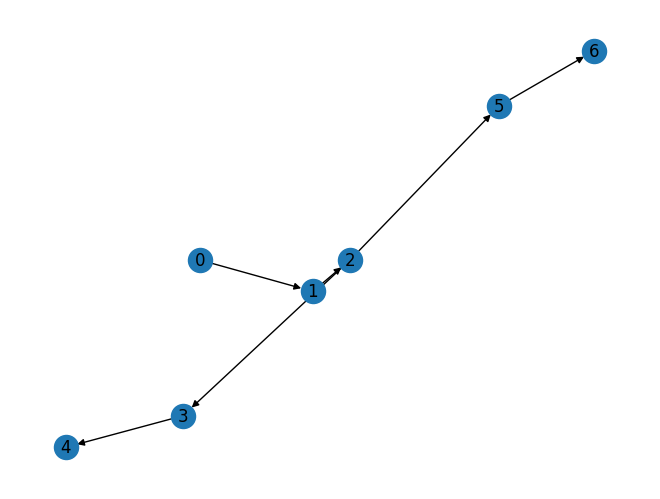

In [11]:
nx.draw(G1, with_labels = True)

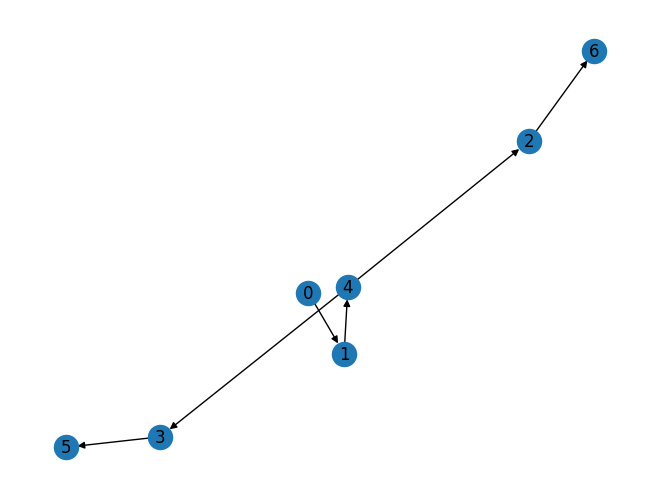

In [12]:
nx.draw(G2, with_labels = True)

# 2. Weisfeiler Lehman (WL) Graph Hash
The Weisfeiler-Lehman (WL) algorithm iteratively aggregates and hashes the neighborhoods of each node. 

- After each node's neighbors are hashed to obtain updated node labels, a hashed histogram of the resulting labels is returned as the final hash.
- Hashes are identical for isomorphic graphs, giving strong guarantees that non-isomorphic graphs will get different hashes.

## 2.1. Undirected graph

In [13]:
G1 = nx.Graph()
G2 = nx.Graph()

G1.add_nodes_from(range(0,7))
G2.add_nodes_from(range(0,7))
G1.add_edges_from([(0,1), (1,2), (2,3), (3,4), (2,5), (5,6)])
G2.add_edges_from([(0,1), (1,4), (2,4), (2,6), (4,3), (3,5)])

g1_hash = nx.weisfeiler_lehman_graph_hash(G1)
g2_hash = nx.weisfeiler_lehman_graph_hash(G2)

# g1_hash and g2_hash are equal when they are isomorphic
print(f"First  graph hash: {g1_hash}")
print(f"Second graph hash: {g2_hash}")
print(f"Checking graph isomorphic: {g1_hash==g2_hash}")

First  graph hash: 61f645001e86ad8a32357cc828ae33cb
Second graph hash: 61f645001e86ad8a32357cc828ae33cb
Checking graph isomorphic: True


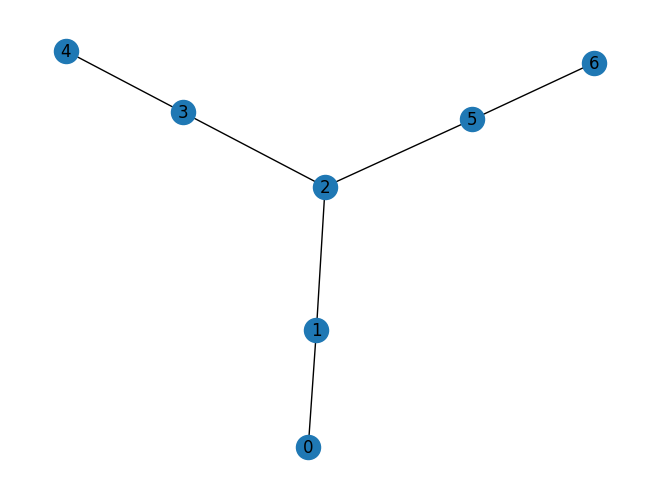

In [14]:
nx.draw(G1, with_labels = True)

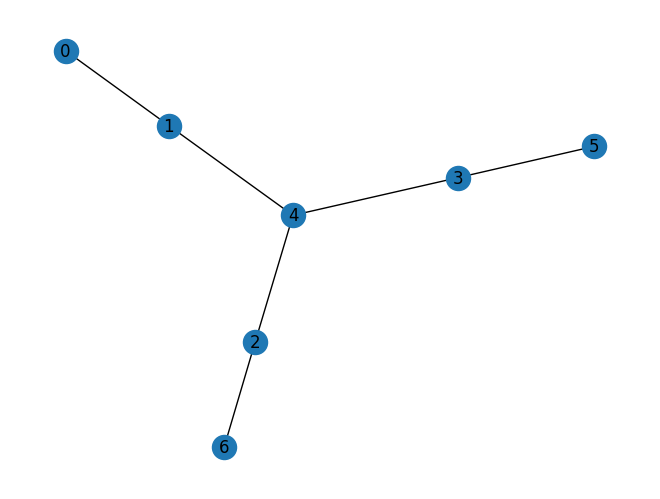

In [15]:
nx.draw(G2, with_labels = True)

## 2.2. Directed graph

In [16]:
G1 = nx.DiGraph()
G2 = nx.DiGraph()

G1.add_nodes_from(range(0,7))
G2.add_nodes_from(range(0,7))
G1.add_edges_from([(0,1), (1,2), (2,3), (3,4), (2,5), (5,6)])
G2.add_edges_from([(0,1), (1,4), (2,4), (2,6), (4,3), (3,5)])

g1_hash = nx.weisfeiler_lehman_graph_hash(G1)
g2_hash = nx.weisfeiler_lehman_graph_hash(G2)

# g1_hash and g2_hash are equal when they are isomorphic
print(f"First  graph hash: {g1_hash}")
print(f"Second graph hash: {g2_hash}")
print(f"Checking graph isomorphic: {g1_hash==g2_hash}")

First  graph hash: 7d77c6474bd3835fe0f19ac0f27881e2
Second graph hash: 9dacf03794ba1624e5a8f373848e5ec5
Checking graph isomorphic: False


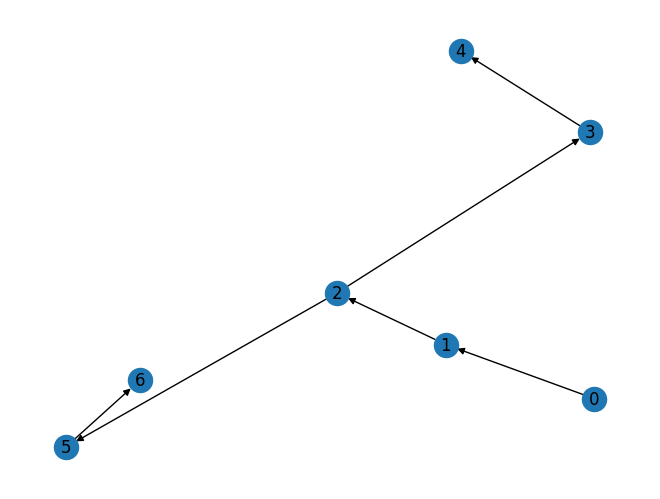

In [17]:
nx.draw(G1, with_labels = True)

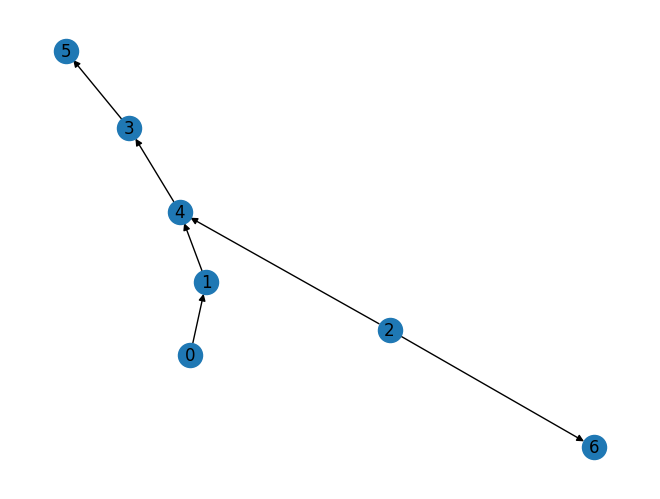

In [18]:
nx.draw(G2, with_labels = True)

# 3. Graphlet Kernels
Graphlets are small, connected, non-isomorphic induced subgraphs. Graphlet kernels count the number of specific graphlets in a graph to construct a feature vector.

Below, we extract graphlets from a given graph and visualize them.

In [19]:
# visualizing all subgraphs
def visualize_subgraph(graph, subgraph_nodes, node_color):
    # get subgraph
    subgraph = nx.subgraph(graph, subgraph_nodes)

    # create visualization
    node_colors = [node_color] * len(subgraph_nodes)
    title = f"Community Partition Subgraph"
    pos = nx.spring_layout(subgraph, 
                           k=0.3, iterations=50,
                           seed=2)

    plt.figure(1,figsize=(8,6)) 
    nx.draw(subgraph,
            pos = pos,
            node_size=1000,
            node_color=node_colors,
            with_labels=True,
            font_size = 20,
            font_color='black')
    plt.title(title)
    plt.show()

In [20]:
import random
r = lambda: random.randint(0,255)
colors = []
for i in range(14):
    colors.append('#%02X%02X%02X' % (r(),r(),r()))
colors

['#8BD1FB',
 '#04CCED',
 '#997829',
 '#3AB159',
 '#DA3C8C',
 '#04797A',
 '#EE4EBE',
 '#29BFE3',
 '#EB5ADA',
 '#D0935A',
 '#E9E76B',
 '#B05A07',
 '#686179',
 '#C75FAA']

[(1, 2), (1, 3)]


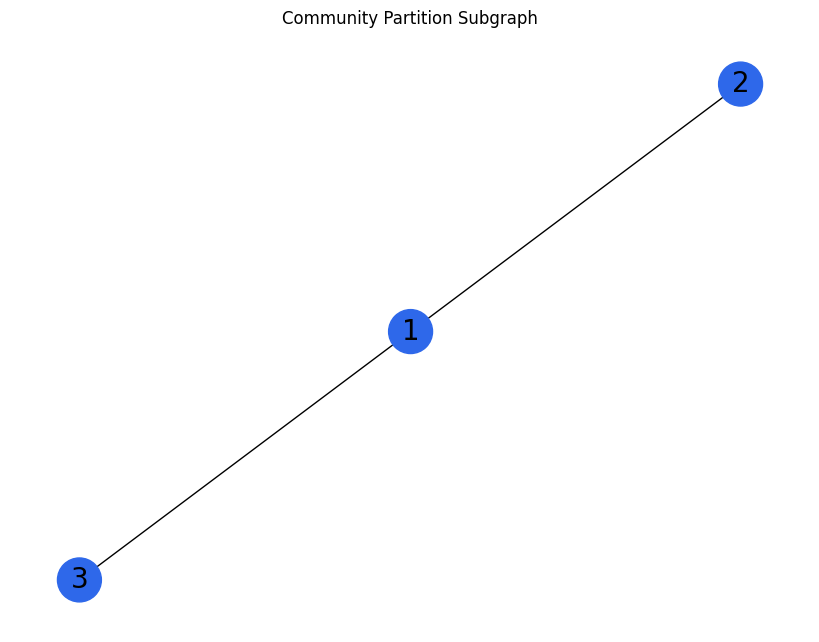

[(1, 2), (1, 7)]


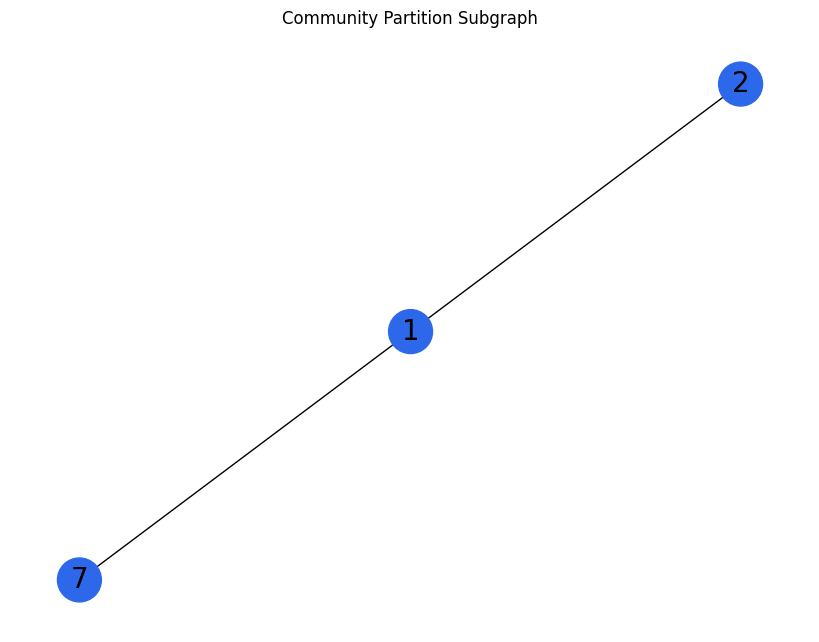

[(1, 2), (2, 4)]


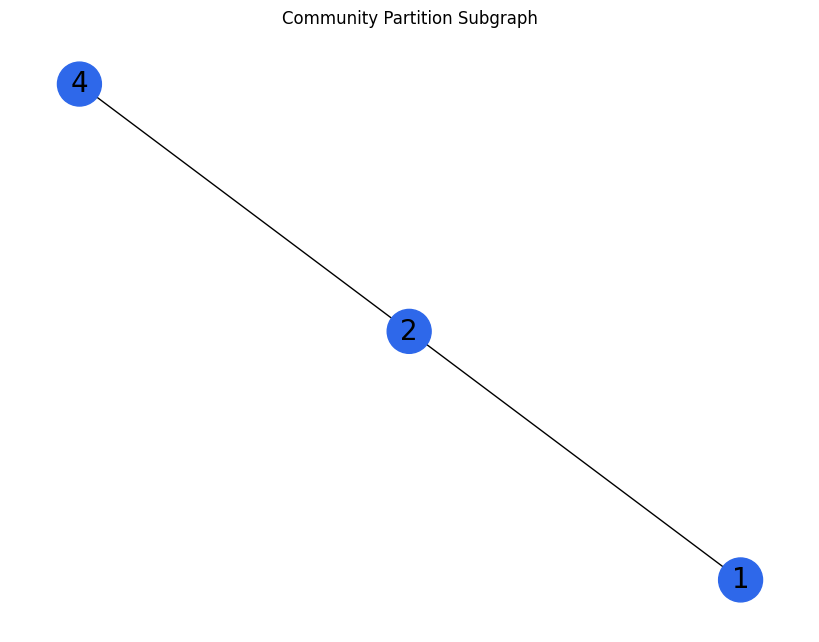

[(1, 3), (1, 7)]


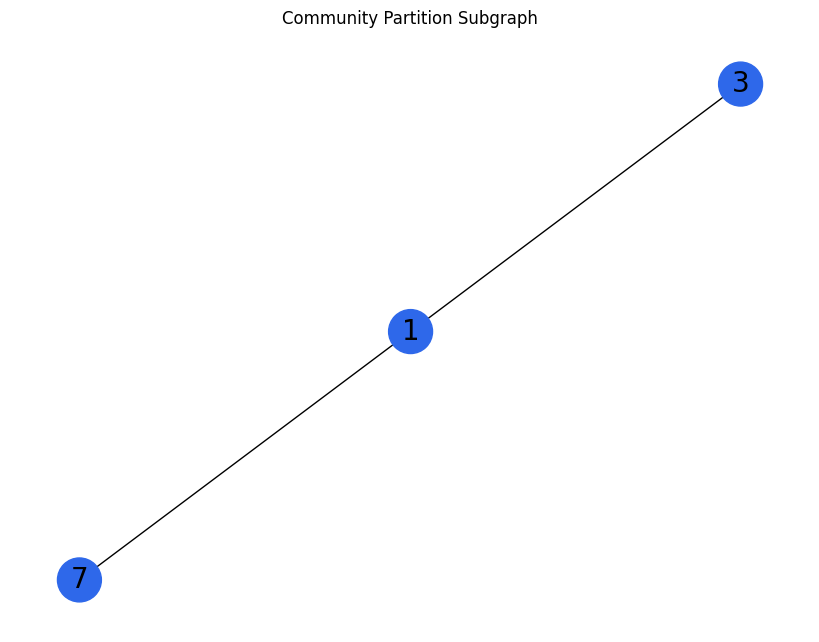

[(1, 3), (3, 4)]


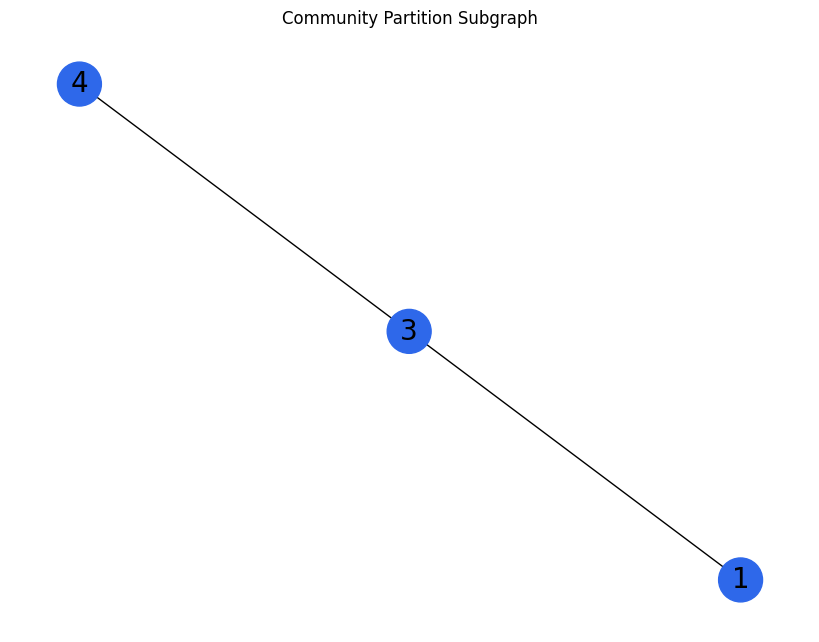

[(1, 3), (3, 5)]


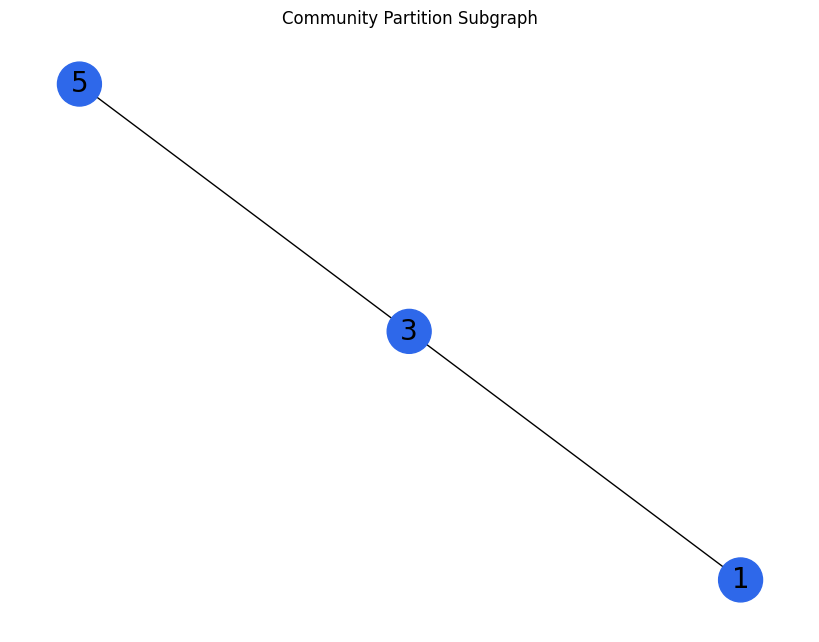

[(1, 3), (3, 6)]


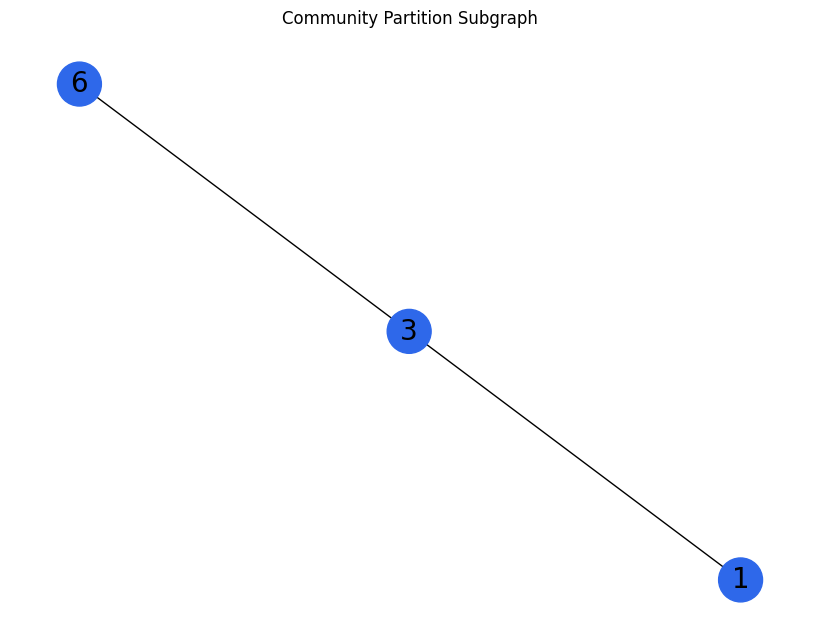

[(1, 7), (6, 7)]


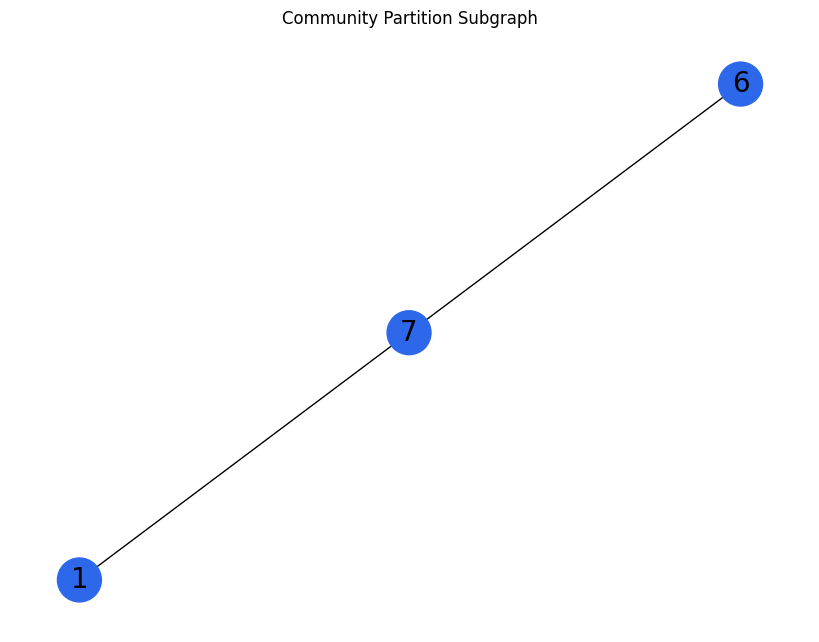

[(2, 4), (3, 4)]


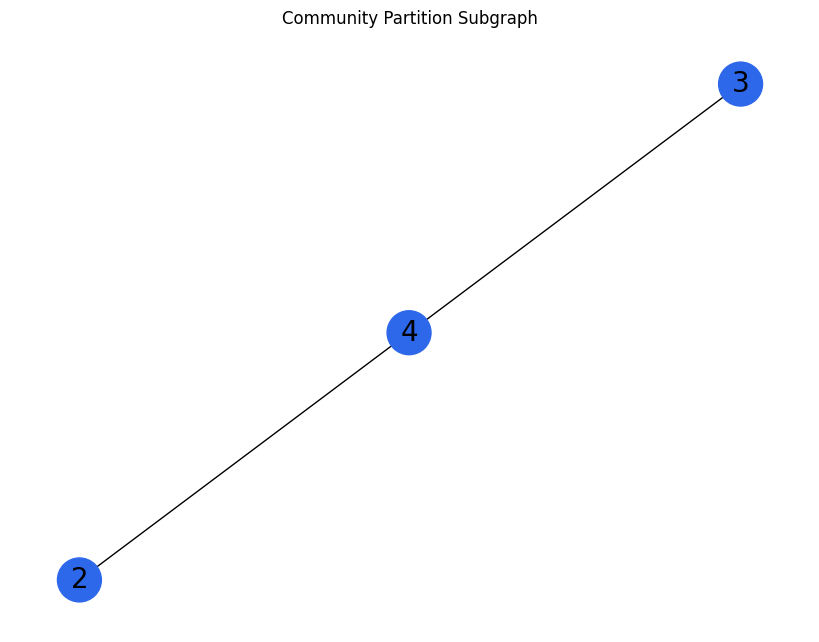

[(2, 4), (4, 5)]


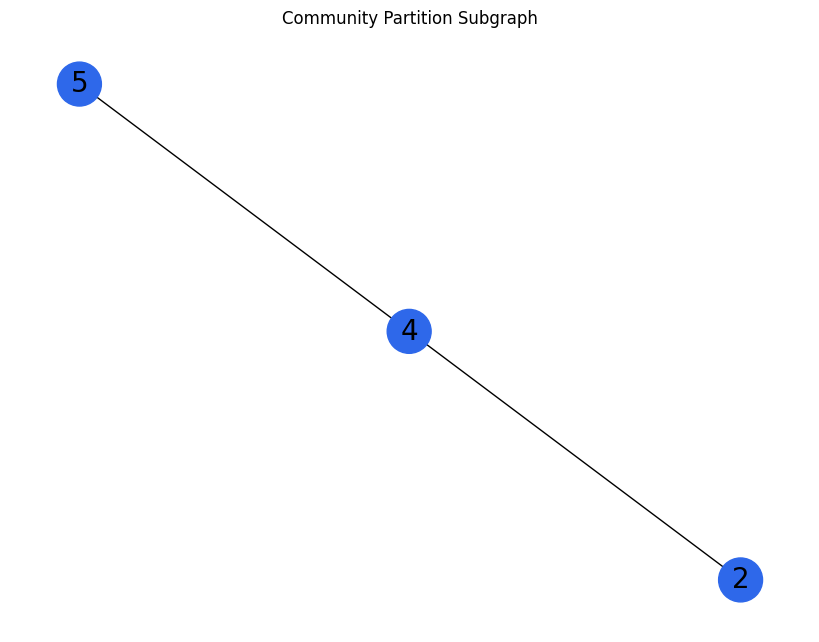

[(3, 6), (6, 7)]


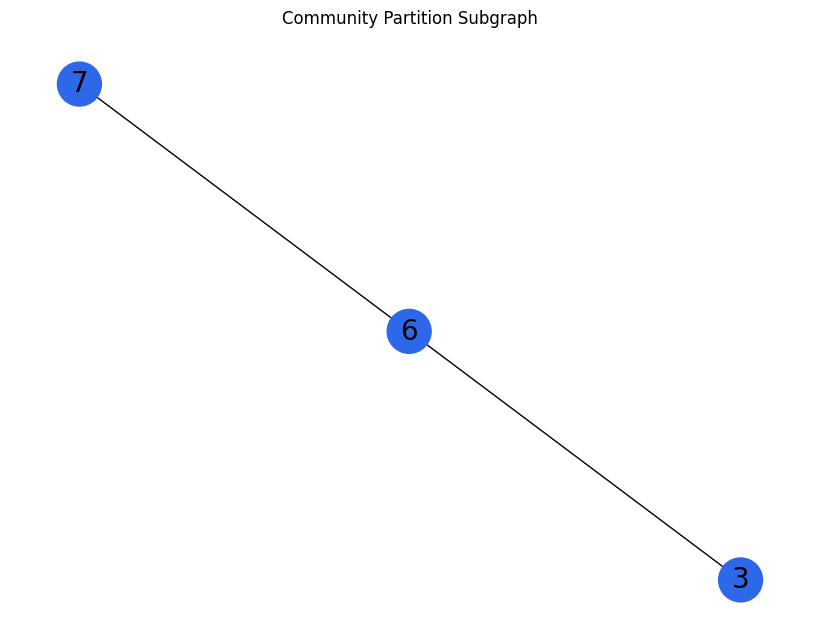

[(3, 4), (3, 6)]


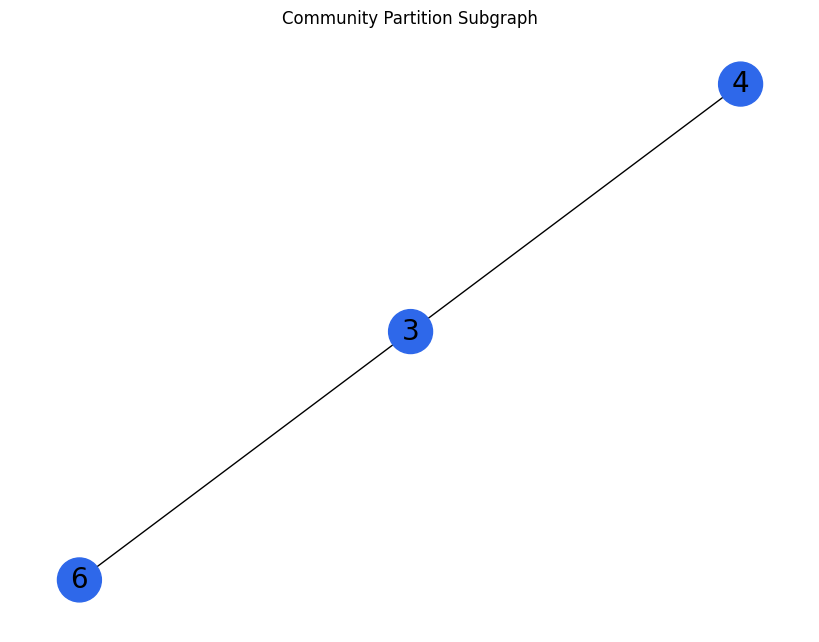

[(5, 6), (6, 7)]


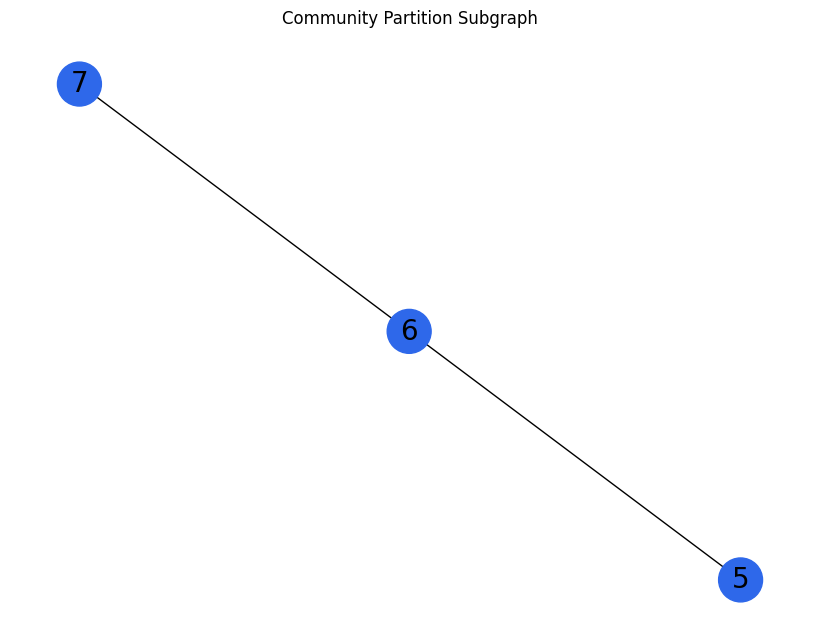

[(4, 5), (5, 6)]


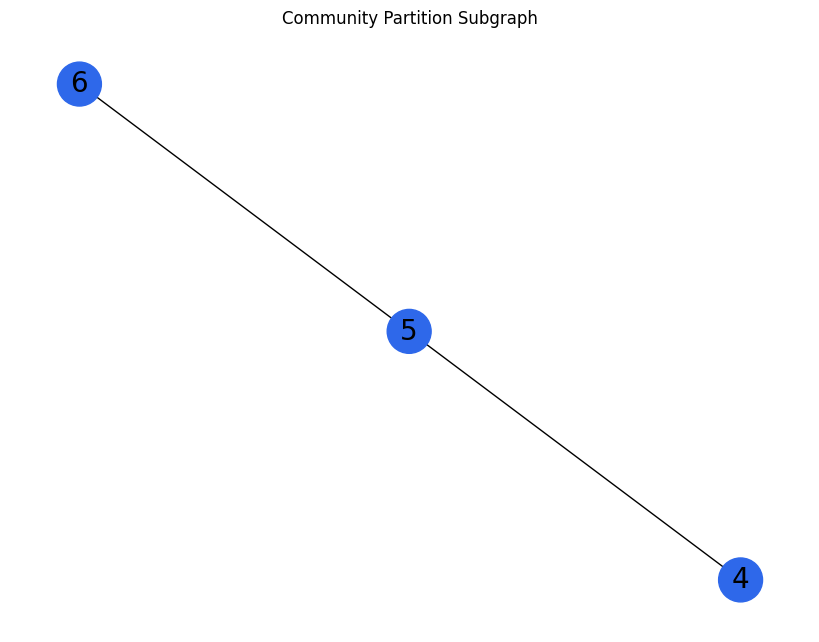

In [21]:
import networkx as nx
import itertools
import matplotlib.pyplot as plt

g = nx.Graph()
g.add_edge(1,2)
g.add_edge(1,3)
g.add_edge(1,7)
g.add_edge(2,4)
g.add_edge(3,4)
g.add_edge(3,5)
g.add_edge(3,6)
g.add_edge(4,5)
g.add_edge(5,6)
g.add_edge(6,7)

target = nx.Graph()
target.add_edge(1,2)
target.add_edge(2,3)

colors = ['#DE7A6D', '#17BDF0',  '#3B88E9', '#212B83', '#EA43F3', '#EA3D11', '#C6A8C9', '#96FE21', 
          '#C53A08', '#56B059', '#8EA7A2', '#BF9207', '#006843', '#2E68EA']
for sub_nodes in itertools.combinations(g.nodes(),len(target.nodes())):
    subg = g.subgraph(sub_nodes)
    if nx.is_connected(subg) and nx.is_isomorphic(subg, target):
        print(subg.edges())
        visualize_subgraph(subg, subg.nodes(), colors[i])

# 4. Chemical Graph Kernels

## 4.1. Shortest Path Kernel

Consider two chemical molecules: $H_2O$ and $H_3O^+$ (an ion of water produced by protonation). 

We compute the Shortest Path Kernel between them. By transforming the node graphs into feature spaces derived from shortest paths, we can check if they share similarities.

[[1.]] [[0.94280904]]


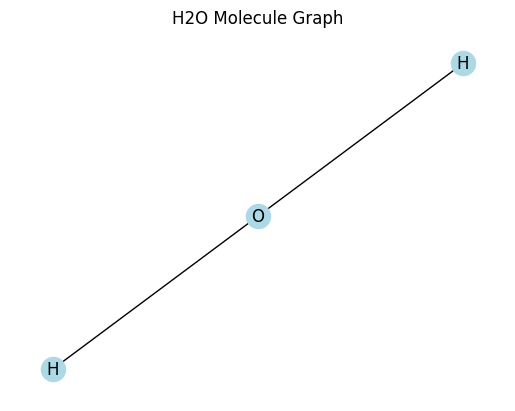

In [22]:
H2O_adjacency = [[0, 1, 1], [1, 0, 0], [1, 0, 0]]
H2O_node_labels = {0: 'O', 1: 'H', 2: 'H'}
H2O = Graph(initialization_object=H2O_adjacency, node_labels=H2O_node_labels)

H3O_adjacency = [[0, 1, 1, 1], [1, 0, 0, 0], [1, 0, 0, 0], [1, 0, 0, 0]]
H3O_node_labels = {0: 'O', 1: 'H', 2: 'H', 3:'H'}
H3O = Graph(initialization_object=H3O_adjacency, node_labels=H3O_node_labels)

sp_kernel = ShortestPath(normalize=True)
g1_sp = sp_kernel.fit_transform([H2O])
g2_sp = sp_kernel.transform([H3O])
print(g1_sp, g2_sp)

H2O_adjacency_mat = np.matrix([[0, 1, 1], [1, 0, 0], [1, 0, 0]])
H3O_adjacency_mat = np.matrix([[0, 1, 1, 1], [1, 0, 0, 0], [1, 0, 0, 0], [1, 0, 0, 0]])

G_h20 = nx.from_numpy_array(H2O_adjacency_mat)
plt.title("H2O Molecule Graph")
nx.draw(G_h20, labels=H2O_node_labels, with_labels=True, node_color='lightblue')

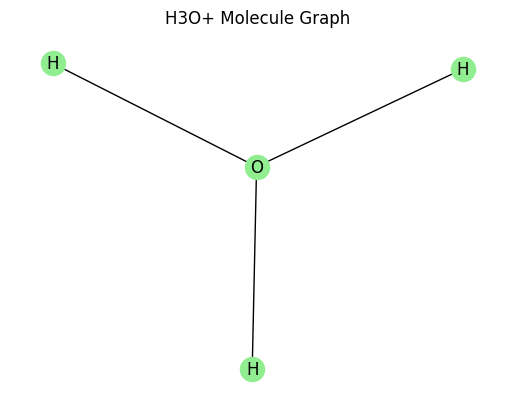

In [23]:
G_h30 = nx.from_numpy_array(H3O_adjacency_mat)
plt.title("H3O+ Molecule Graph")
nx.draw(G_h30, labels=H3O_node_labels, with_labels=True, node_color='lightgreen')

## 4.2. Random Walk Kernel

Consider two molecules: Dimethyl Ether and Ethanol. Both have the same chemical formula ($C_2H_6O$) but different structures (they are isomers).

We compute the Random Walk Kernel to compare their random walk patterns. Because they share many structural similarities, the computed kernel value indicates proximity to what extent they are related.

In [24]:
from grakel import Graph
from grakel.kernels import RandomWalk
import numpy as np

Ethanol_adjacency = [[0, 0, 0, 0, 0, 0, 1, 0, 0],
                     [0, 0, 0, 0, 0, 0, 1, 0, 0], 
                     [0, 0, 0, 0, 0, 0, 0, 1, 0],
                     [0, 0, 0, 0, 0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0, 0, 0, 1, 0],
                     [0, 0, 0, 0, 0, 0, 1, 0, 0],
                     [1, 1, 0, 0, 0, 1, 0, 1, 0],
                     [0, 0, 1, 0, 1, 0, 1, 0, 1],
                     [0, 0, 0, 1, 0, 0, 0, 1, 0],
                    ]
Ethanol_node_labels = {0: 'H', 1: 'H', 2: 'H', 3:'H', 4:'H', 5:'H', 6:'C', 7:'C', 8 :'O'}

Ethanol = Graph(initialization_object=Ethanol_adjacency, node_labels=Ethanol_node_labels)

Dimethyl_Ether_adjacency = [[0, 0, 0, 0, 0, 0, 1, 0, 0],
                     [0, 0, 0, 0, 0, 0, 1, 0, 0], 
                     [0, 0, 0, 0, 0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0, 0, 1, 0, 0],
                     [1, 1, 0, 0, 0, 1, 0, 1, 0],
                     [0, 0, 0, 0, 0, 0, 1, 0, 1],
                     [0, 0, 1, 1, 1, 0, 0, 1, 0],
                    ]
Dimethyl_Ether_node_labels = {0: 'H', 1: 'H', 2: 'H', 3:'H', 4:'H', 5:'H', 6:'C', 7:'O', 8 :'C'}
Dimethyl_Ether = Graph(initialization_object=Dimethyl_Ether_adjacency, node_labels=Dimethyl_Ether_node_labels)

rw_kernel = RandomWalk(normalize=True)
g1_rw = rw_kernel.fit_transform([Ethanol])
g2_rw = rw_kernel.transform([Dimethyl_Ether])
print(g1_rw,g2_rw)

[[1.]] [[0.99860269]]


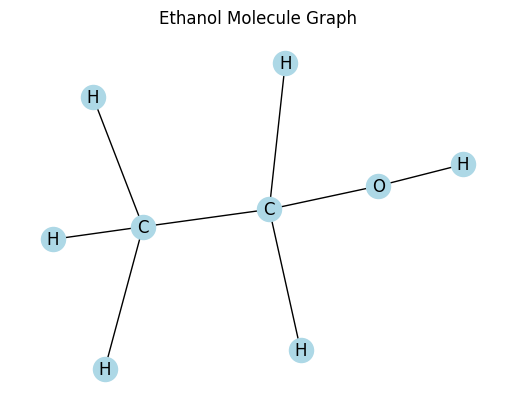

In [25]:
Ethanol_adjacency =  np.matrix([[0, 0, 0, 0, 0, 0, 1, 0, 0],
                     [0, 0, 0, 0, 0, 0, 1, 0, 0], 
                     [0, 0, 0, 0, 0, 0, 0, 1, 0],
                     [0, 0, 0, 0, 0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0, 0, 0, 1, 0],
                     [0, 0, 0, 0, 0, 0, 1, 0, 0],
                     [1, 1, 0, 0, 0, 1, 0, 1, 0],
                     [0, 0, 1, 0, 1, 0, 1, 0, 1],
                     [0, 0, 0, 1, 0, 0, 0, 1, 0],
                    ])

G = nx.from_numpy_array(Ethanol_adjacency)
plt.title("Ethanol Molecule Graph")
nx.draw(G, pos=nx.spring_layout(G), labels=Ethanol_node_labels, with_labels=True, node_color='lightblue')

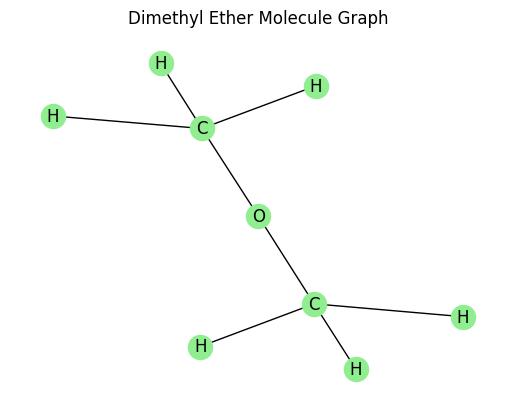

In [26]:
Dimethyl_Ether_adjacency = np.matrix([[0, 0, 0, 0, 0, 0, 1, 0, 0],
                     [0, 0, 0, 0, 0, 0, 1, 0, 0], 
                     [0, 0, 0, 0, 0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0, 0, 0, 0, 1],
                     [0, 0, 0, 0, 0, 0, 1, 0, 0],
                     [1, 1, 0, 0, 0, 1, 0, 1, 0],
                     [0, 0, 0, 0, 0, 0, 1, 0, 1],
                     [0, 0, 1, 1, 1, 0, 0, 1, 0],
                    ])
G_dimethyl = nx.from_numpy_array(Dimethyl_Ether_adjacency)
plt.title("Dimethyl Ether Molecule Graph")
nx.draw(G_dimethyl, pos=nx.spring_layout(G_dimethyl), labels=Dimethyl_Ether_node_labels, with_labels=True, node_color='lightgreen')